# 1. Supervised Machine Learning: Classification

Supervised learning is a type of machine learning where the model is trained on labeled data. Labeled data means that for each input example, we also have the correct corresponding output (label). 

A common supervised learning task is **classification**, where the goal is to predict discrete categories. Let's start with a classic and easy-to-understand dataset: the **Breast Cancer Wisconsin dataset** from `scikit-learn`. Our goal is to predict whether a tumor is malignant (harmful) or benign (safe) based on clinical measurements.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

# General setup for dataset paths
data_folder = '../../data/examples/week_10'

# Load the dataset
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name="target")

# Print target names and show the first few rows
print("Target Classes:", cancer.target_names)
X.head(2)


Target Classes: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902


### 1.1.1 Training a Decision Tree Classifier

Next, we split the dataset into a training set (80%) and a testing set (20%). We then fit a simple Decision Tree Classifier to the training data and check its accuracy on the test set.

In [2]:
# Split the dataset into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the classifier
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# Predict on test data
y_pred = clf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}\n")
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

Accuracy: 94.74%

              precision    recall  f1-score   support

   malignant       0.95      0.91      0.93        43
      benign       0.95      0.97      0.96        71

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



### 1.1.2 Visualizing the Decision Tree

Decision trees are highly interpretable models because we can visualize the exact rules they use to make predictions.

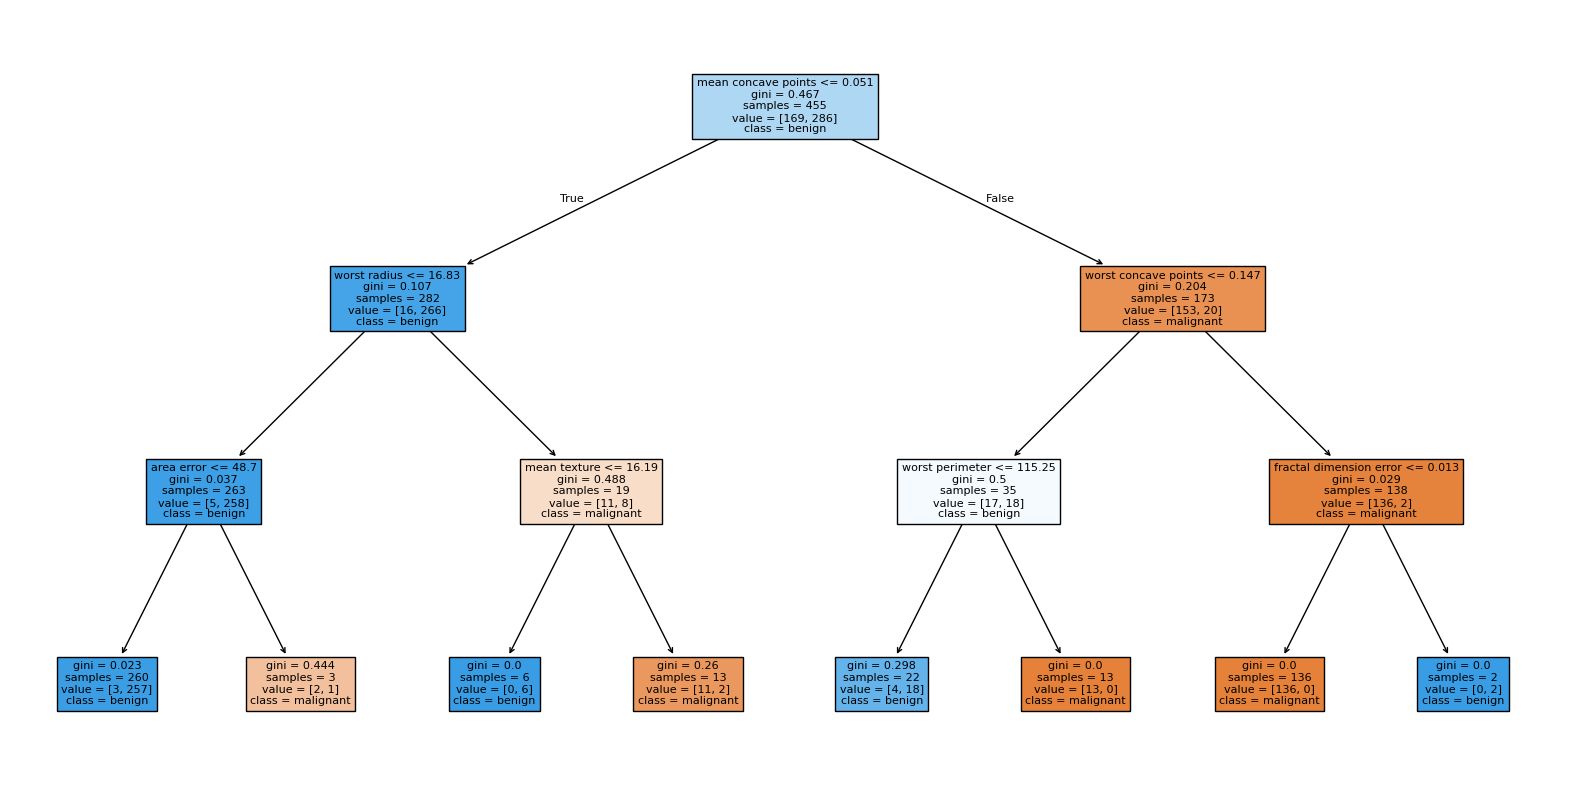

In [3]:
plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=cancer.feature_names, class_names=cancer.target_names, filled=True)
plt.show()

# 2. Unsupervised Machine Learning: Dimension Reduction/PCA

## 2.1 Dimension Reduction/PCA

In [4]:
df_edu = pd.read_csv(f"{data_folder}/education.csv").dropna()
df_edu.head(2)

,region,subregion,country,year,PISA,GDI,GINI,LibDem,Public Spending on Education,Private Spending on Education
18,Oceania,Australia and New Zealand,Australia,2018,503.0,0.971,34.3,0.813,34.792880,34.792880
35,Europe,Western Europe,Austria,2012,490.0,0.975,30.5,0.806,95.143448,95.143448


In [5]:
data = df_edu.set_index(['country','year'])[['GINI', 'LibDem', 'Public Spending on Education', 'Private Spending on Education', 'PISA']]
data.head(2)

,,GINI,LibDem,Public Spending on Education,Private Spending on Education,PISA
country,year,,,,,
Australia,2018,34.3,0.813,34.792880,34.792880,503.0
Austria,2012,30.5,0.806,95.143448,95.143448,490.0


### 2.1.1 Set PCA

In [6]:
from sklearn.decomposition import PCA
pca = PCA(n_components=1) 

In [7]:
principal_components = pca.fit_transform(data.drop(['PISA'], axis='columns'))
df_pca = pd.DataFrame(data=principal_components, columns=['PCA'], index = data.index)
df_pca.head(2)

,,PCA
country,year,
Australia,2018,-49.940339
Austria,2012,34.883874


In [8]:
df_pca = pd.concat([df_pca, data], axis='columns')
df_pca.head(2)

,,PCA,GINI,LibDem,Public Spending on Education,Private Spending on Education,PISA
country,year,,,,,,
Australia,2018,-49.940339,34.3,0.813,34.792880,34.792880,503.0
Austria,2012,34.883874,30.5,0.806,95.143448,95.143448,490.0


### 2.1.2 Scatter and regression

<Axes: xlabel='PCA', ylabel='PISA'>

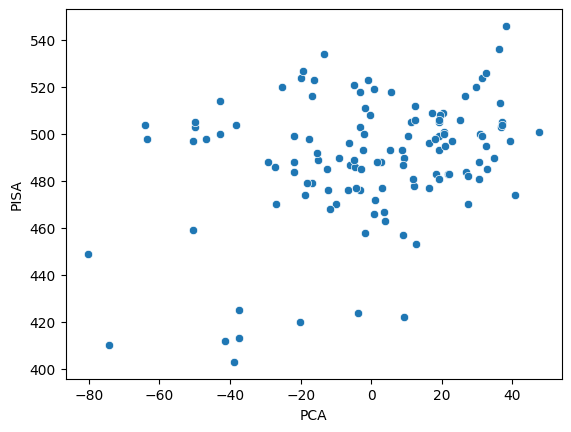

In [9]:
import seaborn as sns
sns.scatterplot(
    data = df_pca,
    y = 'PISA',
    x = 'PCA',
)

<Axes: xlabel='Public Spending on Education', ylabel='PISA'>

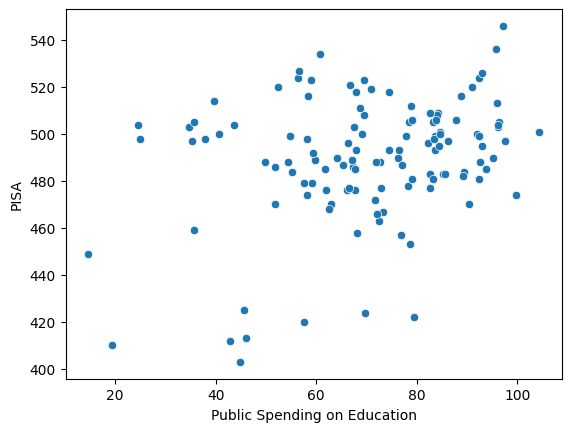

In [10]:
import seaborn as sns
sns.scatterplot(
    data = df_pca,
    y = 'PISA',
    x = 'Public Spending on Education',
)

In [11]:
def regression(data, y, x_cols):
    x = data[x_cols]
    y = data[y]
    x = sm.add_constant(x)
    reg = sm.OLS(y, x).fit() # ROBUST STANDARD ERRORS IN cov_type
    df = pd.concat([reg.params, reg.pvalues], axis=1).round(2)
    df.columns = ['coef', 'pvalue']
    return df

In [12]:

    
regression(
    data = df_pca,
    x_cols = ['PCA'],
    y = 'PISA'
)

,coef,pvalue
const,489.39,0.0
PCA,0.32,0.0


In [13]:
regression(
    data = df_pca,
    x_cols = ['LibDem'],
    y = 'PISA'
)

,coef,pvalue
const,392.09,0.0
LibDem,126.19,0.0


### 2.1.3 You shoud always scale/normalize/zscore before pca

In [14]:
data.head(2)

,,GINI,LibDem,Public Spending on Education,Private Spending on Education,PISA
country,year,,,,,
Australia,2018,34.3,0.813,34.792880,34.792880,503.0
Austria,2012,30.5,0.806,95.143448,95.143448,490.0


In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data.drop(['PISA'], axis='columns'))

from sklearn.decomposition import PCA
pca = PCA(n_components=1) 
principal_components = pca.fit_transform(scaled_data)

df_pca = pd.DataFrame(data=principal_components, columns=['PCA_scaled'], index = data.index)
df_pca.head(2)

,,PCA_scaled
country,year,
Australia,2018,-2.122840
Austria,2012,1.793649


In [16]:
df_pca = pd.concat([df_pca, data], axis='columns')
df_pca.head(2)

,,PCA_scaled,GINI,LibDem,Public Spending on Education,Private Spending on Education,PISA
country,year,,,,,,
Australia,2018,-2.122840,34.3,0.813,34.792880,34.792880,503.0
Austria,2012,1.793649,30.5,0.806,95.143448,95.143448,490.0


<Axes: xlabel='PCA_scaled', ylabel='PISA'>

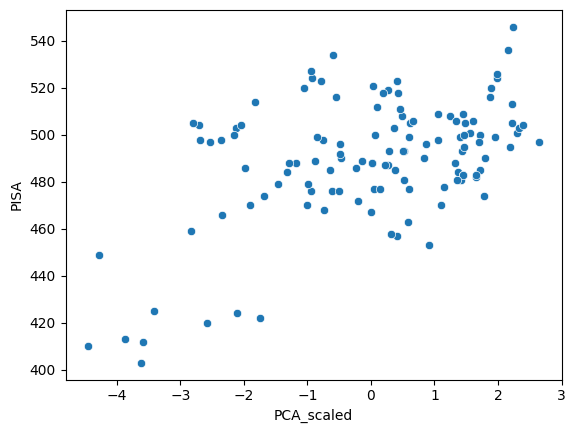

In [17]:
import seaborn as sns
sns.scatterplot(
    data = df_pca,
    y = 'PISA',
    x = 'PCA_scaled',
)

<Axes: xlabel='Public Spending on Education', ylabel='PISA'>

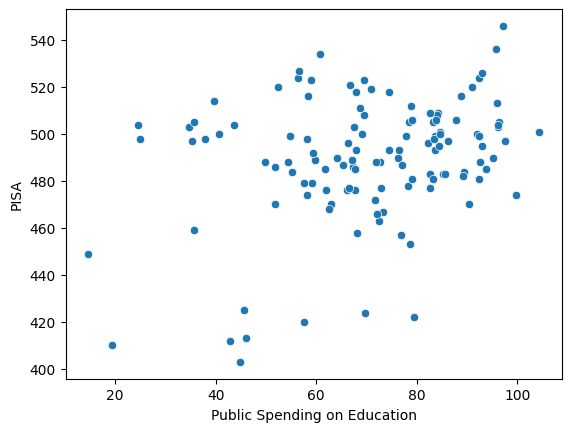

In [18]:
import seaborn as sns
sns.scatterplot(
    data = df_pca,
    y = 'PISA',
    x = 'Public Spending on Education',
)

### 2.1.4 Using PCA or other technique to create index

<Axes: xlabel='country'>

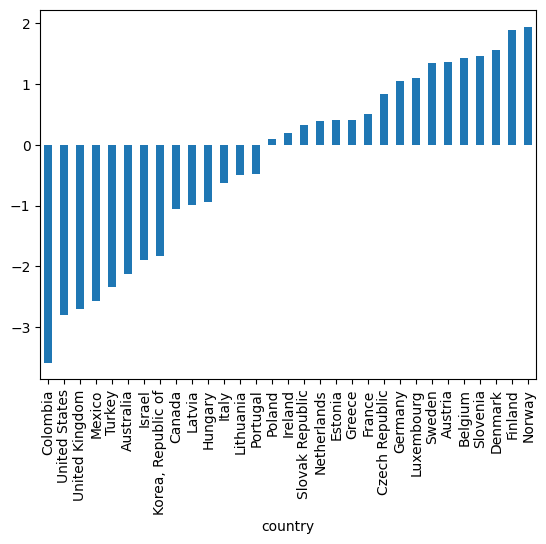

In [19]:
df_pca.query("year == 2018").sort_values('PCA_scaled').droplevel(axis=0, level= 'year')['PCA_scaled'].plot(kind ='bar')

# 3. Regression

In [20]:
import os
import pandas as pd
data_folder = '../../data/examples/week_10'
os.listdir(data_folder)
df = pd.read_csv(f"{data_folder}/democracy_gdp.csv")
df.head(2)

,country,year,v2x_frassoc_thick,NGDPDPC,NGDP_RPCH,v2x_pubcorr,v2xnp_regcorr,v2xel_frefair,v2x_freexp,v2elembcap
0,AFG,1990,0.063,NaN,NaN,0.556,0.538,0.069,0.085,-1.65
1,AFG,1991,0.068,NaN,NaN,0.556,0.538,0.069,0.074,-1.65


## 3.1 Basic regression

In [21]:
df_regression = df[['country', 'year','NGDPDPC', 'v2x_freexp']].dropna()
df_regression.head(2)

,country,year,NGDPDPC,v2x_freexp
105,Asia (avg),1990,3749.756571,0.424697
106,Asia (avg),1991,4234.663571,0.444273


### 3.1.1 Always scatter

<Axes: xlabel='v2x_freexp', ylabel='NGDPDPC'>

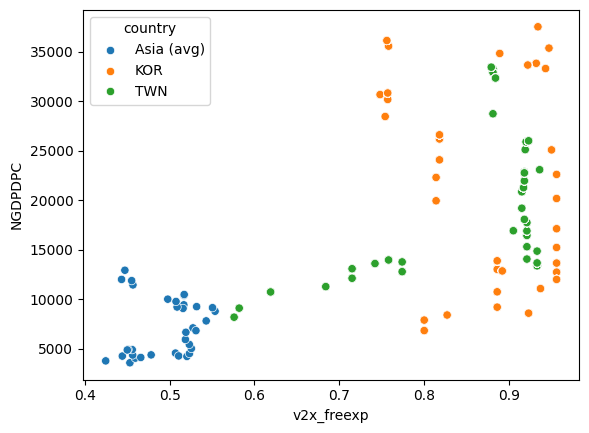

In [22]:
import seaborn as sns
sns.scatterplot(
    data = df_regression,
    y = 'NGDPDPC',
    x = 'v2x_freexp',
    hue = 'country'
)

### 3.1.2 Scatter

In [23]:
y_col = 'NGDPDPC'
x_col = 'v2x_freexp'
x = df_regression[x_col]
y = df_regression[y_col]

In [24]:
import statsmodels.api as sm
reg = sm.OLS(y, x).fit()
reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                NGDPDPC   R-squared (uncentered):                   0.848
Model:                            OLS   Adj. R-squared (uncentered):              0.848
Method:                 Least Squares   F-statistic:                          2.525e+04
Date:                Mon, 22 Jun 2026   Prob (F-statistic):                        0.00
Time:                        09:29:07   Log-Likelihood:                         -47310.
No. Observations:                4515   AIC:                                  9.462e+04
Df Residuals:                    4514   BIC:                                  9.463e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
v2x_freexp  2.353e+04    148.063    158.899      0.000    2.32e+04    2.38e+04
==============================================================================
Omnibus:                     1140.004   Durbin-Watson:                   0.003
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              362.912
Skew:                           0.486   Prob(JB):                     1.57e-79
Kurtosis:                       2.008   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### 3.1.3 Add log then regress

In [25]:
import numpy as np
df_regression = df[['country', 'year','NGDPDPC', 'v2x_freexp']].dropna()
df_regression['NGDPDPC_log'] = df_regression['NGDPDPC'].apply(np.log)
df_regression['v2x_freexp_scale'] = df_regression['v2x_freexp'].multiply(100)
df_regression.head(2)

,country,year,NGDPDPC,v2x_freexp,NGDPDPC_log,v2x_freexp_scale
105,Asia (avg),1990,3749.756571,0.424697,8.229446,42.469697
106,Asia (avg),1991,4234.663571,0.444273,8.351059,44.427273


<Axes: xlabel='v2x_freexp_scale', ylabel='NGDPDPC_log'>

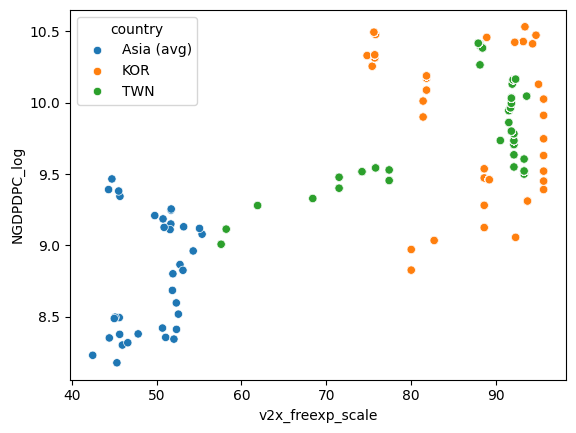

In [26]:
import seaborn as sns
sns.scatterplot(
    data = df_regression,
    y = 'NGDPDPC_log',
    x = 'v2x_freexp_scale',
    hue = 'country'
)

### 3.1.4 1 pt increase in feedom in expression associated with 1.3% higher GDP

In [27]:
def regression(data, y, x):
    x = data[x]
    y = data[y]
    x = sm.add_constant(x)
    reg = sm.OLS(y, x).fit()
    return reg.summary()

regression(
    data = df_regression,
    y =  'NGDPDPC_log',
    x = 'v2x_freexp'
)

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            NGDPDPC_log   R-squared:                       0.086
Model:                            OLS   Adj. R-squared:                  0.086
Method:                 Least Squares   F-statistic:                     424.4
Date:                Mon, 22 Jun 2026   Prob (F-statistic):           3.35e-90
Time:                        09:29:09   Log-Likelihood:                -2715.4
No. Observations:                4515   AIC:                             5435.
Df Residuals:                    4513   BIC:                             5448.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.6312      0.058    149.198      0.000       8.518       8.745
v2x_freexp     1.3788      0.067     20.601      0.000       1.248       1.510
==============================================================================
Omnibus:                      707.005   Durbin-Watson:                   0.004
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              162.269
Skew:                          -0.005   Prob(JB):                     5.80e-36
Kurtosis:                       2.071   Cond. No.                         17.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## 3.2 Robust Standard errors

In [28]:
def regression(data, y, x):
    x = data[x]
    y = data[y]
    x = sm.add_constant(x)
    reg = sm.OLS(y, x).fit(cov_type = 'HC1') # ROBUST STANDARD ERRORS IN cov_type
    return reg.pvalues

regression(
    data = df_regression,
    y =  'NGDPDPC_log',
    x = 'v2x_freexp'
)

const         0.000000e+00
v2x_freexp    5.614891e-97
dtype: float64

## 3.3 Panel Data

### 3.3.1 Easy way

In [29]:
import statsmodels.formula.api as smf
smf.ols(formula='NGDPDPC_log ~ v2x_freexp_scale', data=df_regression).fit().params

Intercept           8.631178
v2x_freexp_scale    0.013788
dtype: float64

In [30]:
smf.ols(formula='NGDPDPC_log ~ v2x_freexp_scale + C(country)', data=df_regression).fit().params

Intercept            8.208610
C(country)[T.KOR]    0.631169
C(country)[T.TWN]    0.578734
v2x_freexp_scale     0.011719
dtype: float64

### 3.3.2 Difficult way

In [31]:
df_dummies = pd.get_dummies(df_regression['country'], drop_first = True).astype(int)
df_dummies.head(2)

,KOR,TWN
105,0,0
106,0,0


In [32]:
df_regression = pd.merge(
    df_regression,
    df_dummies,
    right_index = True,
    left_index = True
)
df_regression.head(2)

,country,year,NGDPDPC,v2x_freexp,NGDPDPC_log,v2x_freexp_scale,KOR,TWN
105,Asia (avg),1990,3749.756571,0.424697,8.229446,42.469697,0,0
106,Asia (avg),1991,4234.663571,0.444273,8.351059,44.427273,0,0


In [33]:
def regression(data, y, x_cols):
    x = data[x_cols]
    y = data[y]
    x = sm.add_constant(x)
    reg = sm.OLS(y, x).fit() # ROBUST STANDARD ERRORS IN cov_type
    return reg.params

regression(
    data = df_regression,
    y =  'NGDPDPC_log',
    x_cols = ['KOR', 'TWN', 'v2x_freexp_scale']
)

const               8.208610
KOR                 0.631169
TWN                 0.578734
v2x_freexp_scale    0.011719
dtype: float64

## 3.4 Decision Tree Regression

In [34]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

In [35]:
X = df_pca.drop(['PISA', 'PCA_scaled'], axis='columns')
y = df_pca['PISA']
dtree = DecisionTreeRegressor(max_depth = 3)
dtree.fit(X, y)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

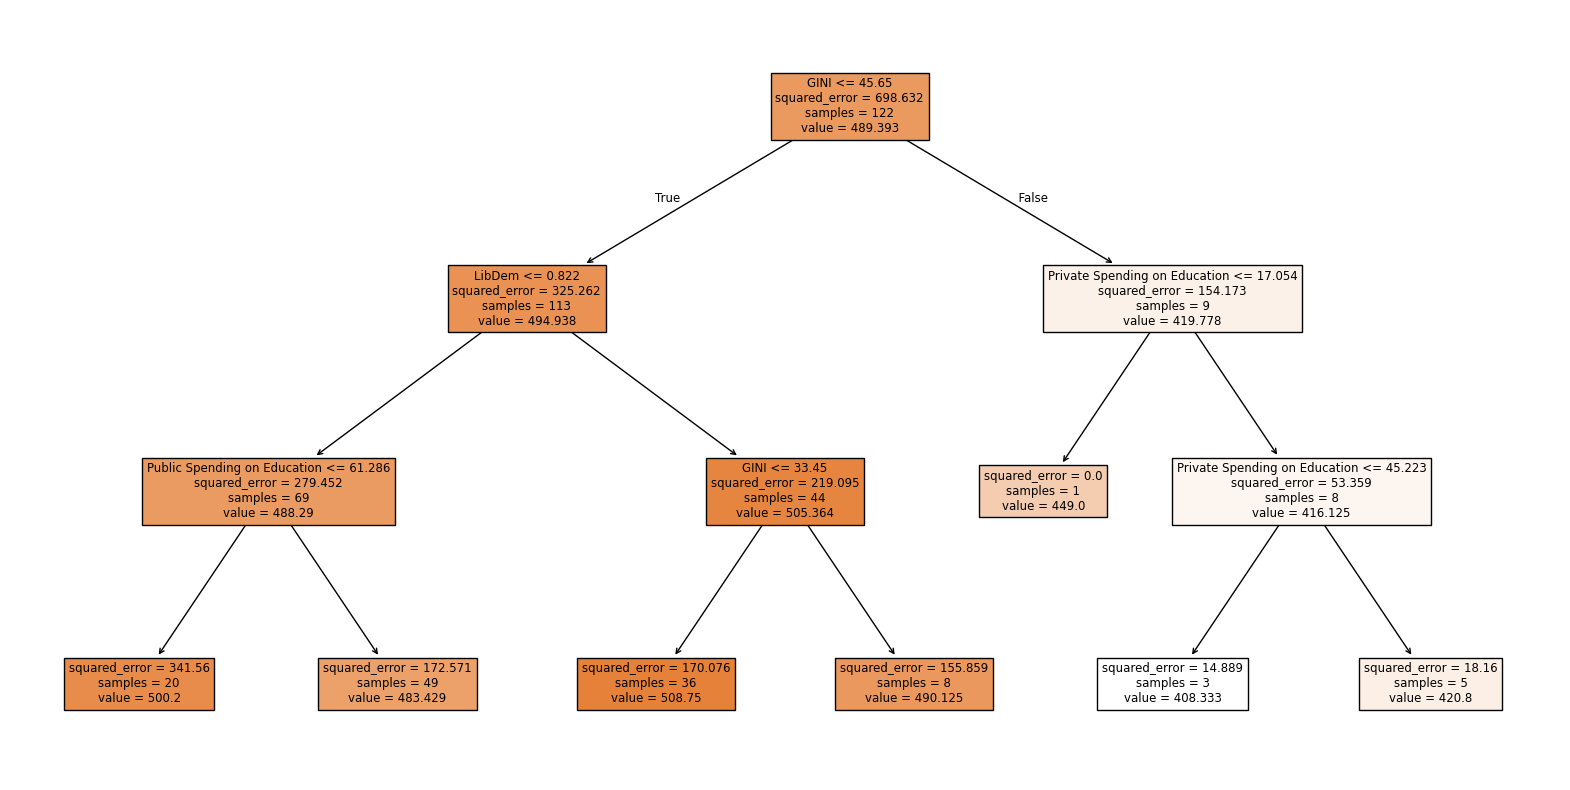

In [36]:
plt.figure(figsize=(20,10))
plot_tree(dtree, feature_names=X.columns, filled=True)
plt.show()